# EEG Motor Imagery — Offline Model Training (v3)

**Dataset:** PhysioNet EEG Motor Movement/Imagery · Runs 4, 8, 12  
**Task:** Binary classification · Left Fist (T1) vs Right Fist (T2)  
**Author:** Aryan · TU Dublin MSc Data Science  

---

## What this notebook does

| Stage | Detail |
|---|---|
| Data | PhysioNet EEGBCI · 20 subjects · runs 4 / 8 / 12 |
| Preprocessing | Band-pass 8–30 Hz · 9 motor-cortex channels |
| Augmentation | Gaussian noise · Channel dropout · Amplitude scaling · SMOTE |
| Classical | LDA · Random Forest · MLP · SVM — **Optuna auto-tuning** |
| Deep learning | **EEGNet CNN** · **1D-CNN** · **BiLSTM + Attention** |
| Auto-select | Best model chosen by test macro-F1 · saved automatically |
| Output | 7 trained models · scaler · metadata JSON · 15 plots |


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    print("Colab detected — installing packages...")
    cmds = [
        "pip install mne==1.7.0 optuna imbalanced-learn -q",
        "pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q",
    ]
    for c in cmds:
        subprocess.run(c, shell=True)
    print("Done.")
else:
    print("Local env — assuming packages installed.")


Colab detected — installing packages...
Done.


In [2]:
import os, json, warnings, copy, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import welch
from scipy.integrate import simpson

import mne
from mne.datasets import eegbci

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, LeaveOneGroupOut
)
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)
import joblib

# ── Optuna ────────────────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── SMOTE ─────────────────────────────────────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_OK = True
except ImportError:
    SMOTE_OK = False
    print("[WARN] imbalanced-learn not found; SMOTE will be skipped.")

# ── PyTorch ───────────────────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch {torch.__version__}  device = {DEVICE}")
except ImportError:
    TORCH_OK = False
    DEVICE   = None
    print("[WARN] PyTorch not found — deep learning will be skipped.")

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
if TORCH_OK:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

# ── Output directories ────────────────────────────────────────────────────────
MODELS_DIR  = Path('models')
RESULTS_DIR = Path('results')
FIGS_DIR    = RESULTS_DIR / 'figures'
for d in [MODELS_DIR, RESULTS_DIR, FIGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"MNE {mne.__version__}  NumPy {np.__version__}  Pandas {pd.__version__}")
print("Output dirs ready.")


PyTorch 2.10.0+cu128  device = cuda
MNE 1.7.0  NumPy 2.0.2  Pandas 2.2.2
Output dirs ready.


---
## 1 · Configuration — change the whole pipeline from here


In [3]:
# ── All tunable constants ─────────────────────────────────────────────────────
SUBJECTS      = list(range(1, 21))   # 20 subjects
RUNS          = [4, 8, 12]           # imagined movement runs
FMIN, FMAX    = 8.0, 30.0            # band-pass Hz  (mu + beta)
MU_BAND       = (8.0,  13.0)
BETA_BAND     = (13.0, 30.0)
MOTOR_CHS     = ['C3','C1','Cz','C2','C4','FC3','FC4','CP3','CP4']
TMIN, TMAX    = 0.5, 3.5             # epoch window relative to cue (s)
BASELINE      = None
EVENT_ID      = {'T1': 2, 'T2': 3}  # T1=left, T2=right
TEST_SIZE     = 0.20
OPTUNA_TRIALS = 30                   # Optuna trials per classical model
OPTUNA_CV     = 3                    # inner CV folds

print("Config loaded.")
print(f"  Subjects : {SUBJECTS[0]}–{SUBJECTS[-1]}  (n={len(SUBJECTS)})")
print(f"  Runs     : {RUNS}")
print(f"  Filter   : {FMIN}–{FMAX} Hz")
print(f"  Channels : {MOTOR_CHS}")
print(f"  Epoch    : [{TMIN}, {TMAX}] s")
print(f"  Optuna   : {OPTUNA_TRIALS} trials x {OPTUNA_CV}-fold CV")


Config loaded.
  Subjects : 1–20  (n=20)
  Runs     : [4, 8, 12]
  Filter   : 8.0–30.0 Hz
  Channels : ['C3', 'C1', 'Cz', 'C2', 'C4', 'FC3', 'FC4', 'CP3', 'CP4']
  Epoch    : [0.5, 3.5] s
  Optuna   : 30 trials x 3-fold CV


---
## 2 · Data Loading from PhysioNet
MNE downloads EDF files automatically. Files are cached after the first run.


In [4]:
raw_files     = []   # list of (subj, run, raw)
metadata_rows = []

print("Downloading / loading PhysioNet EEGBCI data...")
t0 = time.time()

for subj in SUBJECTS:
    for run in RUNS:
        fnames = eegbci.load_data(subj, run, verbose=False)
        raw    = mne.io.read_raw_edf(fnames[0], preload=True, verbose=False)
        mne.datasets.eegbci.standardize(raw)   # map to 10-20 names

        annots  = raw.annotations
        t1_cnt  = sum(1 for d in annots.description if d == 'T1')
        t2_cnt  = sum(1 for d in annots.description if d == 'T2')
        raw_files.append((subj, run, raw))
        metadata_rows.append({
            'subject': subj, 'run': run,
            'sfreq': raw.info['sfreq'],
            'n_ch': len(raw.ch_names),
            'duration_s': round(raw.times[-1], 1),
            'T1': t1_cnt, 'T2': t2_cnt,
        })

meta_df = pd.DataFrame(metadata_rows)
print(f"Loaded {len(raw_files)} recordings in {time.time()-t0:.1f}s")
print(meta_df.head(9).to_string(index=False))


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y


Loaded 60 recordings in 842.2s
 subject  run  sfreq  n_ch  duration_s  T1  T2
       1    4  160.0    64       125.0   8   7
       1    8  160.0    64       125.0   8   7
       1   12  160.0    64       125.0   7   8
       2    4  160.0    64       123.0   7   8
       2    8  160.0    64       123.0   8   7
       2   12  160.0    64       123.0   8   7
       3    4  160.0    64       125.0   8   7
       3    8  160.0    64       125.0   7   8
       3   12  160.0    64       125.0   8   7


---
## 3 · Exploratory Data Analysis


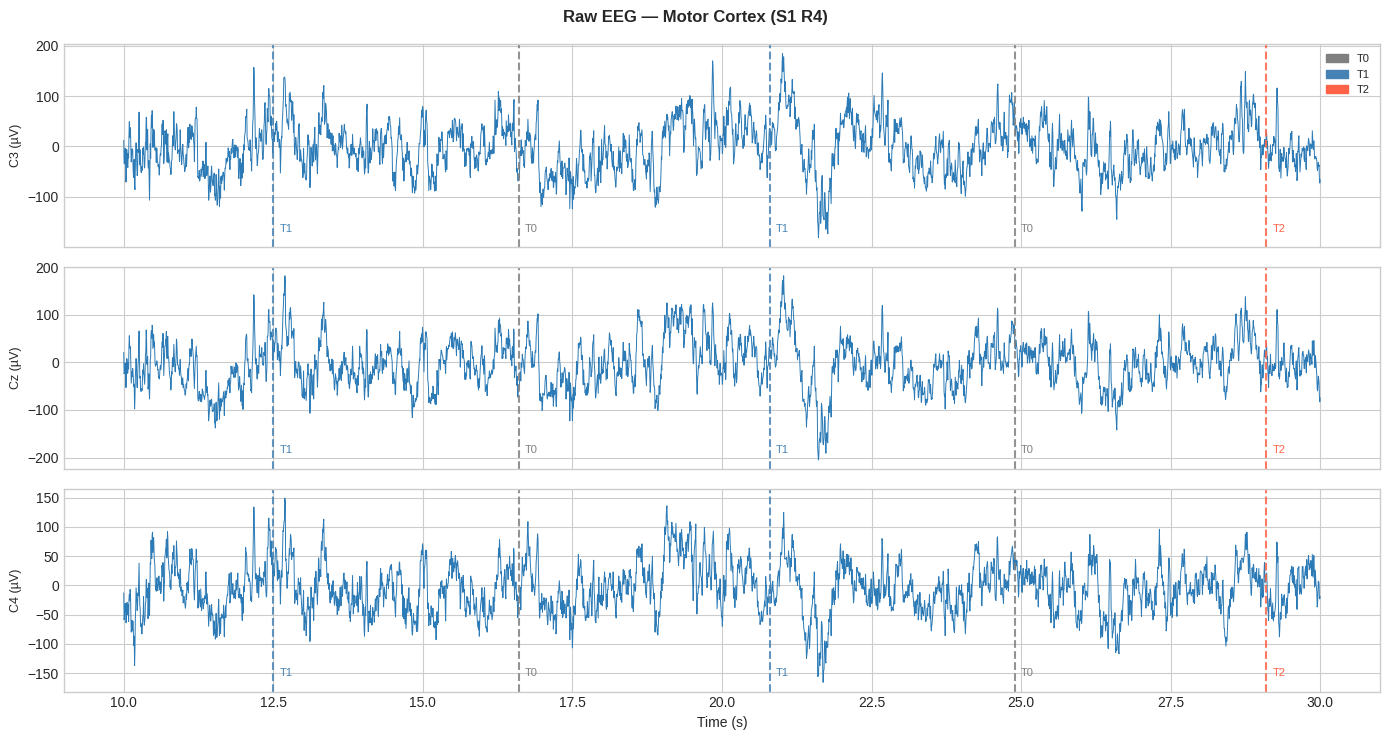

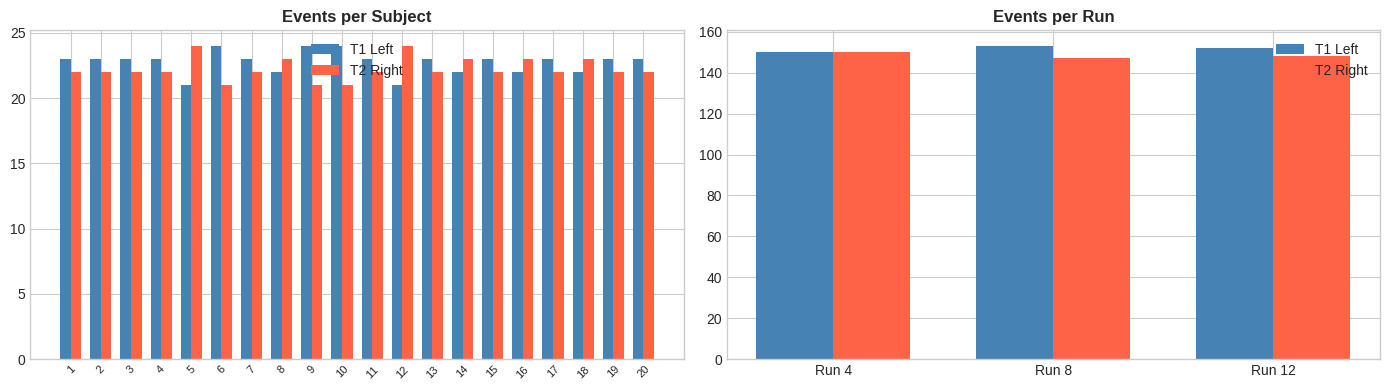

Total  T1=455  T2=445  balance=50.6% / 49.4%


In [5]:
# ── 3.1 Raw EEG at motor channels ────────────────────────────────────────────
s_d, r_d, raw_d = raw_files[0]
avail = [c for c in ['C3','Cz','C4'] if c in raw_d.ch_names]
raw_p = raw_d.copy().pick_channels(avail)
data_p, times_p = raw_p[:, :]
t0_p, t1_p = 10, 30
mask_p = (times_p >= t0_p) & (times_p <= t1_p)
ecol = {'T0':'gray','T1':'steelblue','T2':'tomato'}

fig, axes = plt.subplots(len(avail), 1, figsize=(14, 2.5*len(avail)), sharex=True)
if len(avail) == 1: axes = [axes]
for i, (ch, ax) in enumerate(zip(avail, axes)):
    ax.plot(times_p[mask_p], data_p[i, mask_p]*1e6, color='#2c7bb6', lw=0.7)
    ax.set_ylabel(f'{ch} (µV)', fontsize=9)
    for ann in raw_d.annotations:
        ons = ann['onset']
        if t0_p <= ons <= t1_p:
            col = ecol.get(ann['description'], 'purple')
            ax.axvline(ons, color=col, lw=1.5, ls='--', alpha=0.85)
            ax.text(ons+0.1, ax.get_ylim()[0]*0.85,
                    ann['description'], fontsize=8, color=col)
axes[-1].set_xlabel('Time (s)', fontsize=10)
fig.suptitle(f'Raw EEG — Motor Cortex (S{s_d} R{r_d})',
             fontsize=12, fontweight='bold')
patches = [mpatches.Patch(color=c, label=l) for l, c in ecol.items()]
axes[0].legend(handles=patches, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(FIGS_DIR/'raw_eeg.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3.2 Event counts ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
per_s = meta_df.groupby('subject')[['T1','T2']].sum().reset_index()
x, w  = np.arange(len(per_s)), 0.35
ax[0].bar(x-w/2, per_s['T1'], w, label='T1 Left',  color='steelblue')
ax[0].bar(x+w/2, per_s['T2'], w, label='T2 Right', color='tomato')
ax[0].set_xticks(x); ax[0].set_xticklabels(per_s['subject'], fontsize=8, rotation=45)
ax[0].set_title('Events per Subject', fontweight='bold'); ax[0].legend()

per_r = meta_df.groupby('run')[['T1','T2']].sum().reset_index()
xr = np.arange(len(per_r))
ax[1].bar(xr-w/2, per_r['T1'], w, label='T1 Left',  color='steelblue')
ax[1].bar(xr+w/2, per_r['T2'], w, label='T2 Right', color='tomato')
ax[1].set_xticks(xr); ax[1].set_xticklabels([f'Run {r}' for r in per_r['run']])
ax[1].set_title('Events per Run', fontweight='bold'); ax[1].legend()
plt.tight_layout()
plt.savefig(FIGS_DIR/'event_dist.png', dpi=150, bbox_inches='tight')
plt.show()

t1_tot = meta_df['T1'].sum(); t2_tot = meta_df['T2'].sum()
print(f"Total  T1={t1_tot}  T2={t2_tot}  "
      f"balance={t1_tot/(t1_tot+t2_tot)*100:.1f}% / {t2_tot/(t1_tot+t2_tot)*100:.1f}%")


---
## 4 · Preprocessing Pipeline
Functions are written identically to the Streamlit app so both share the exact same pipeline.


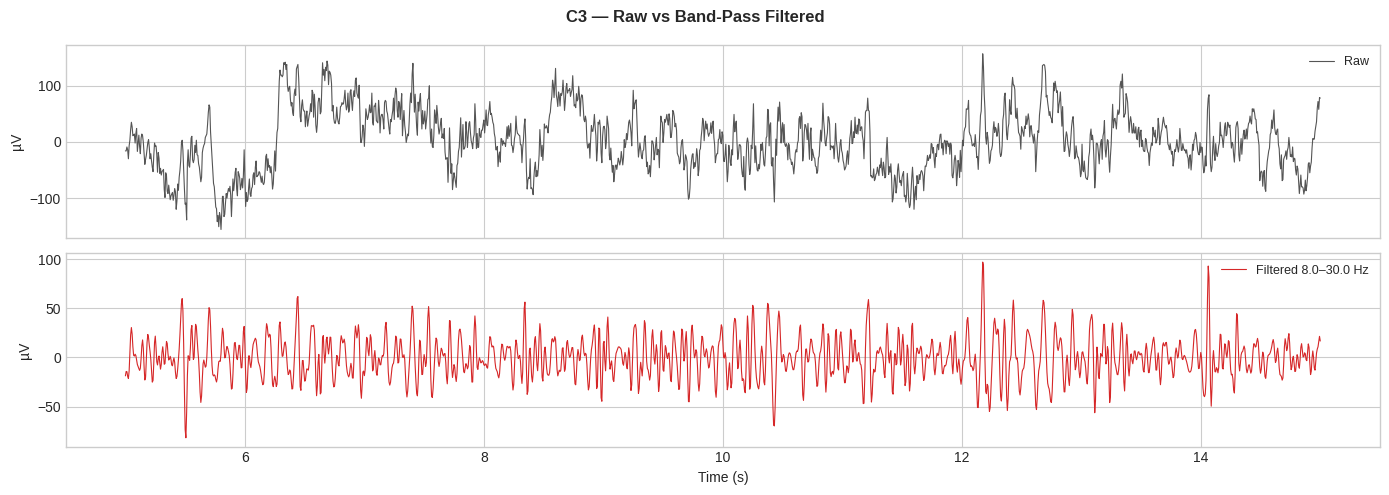

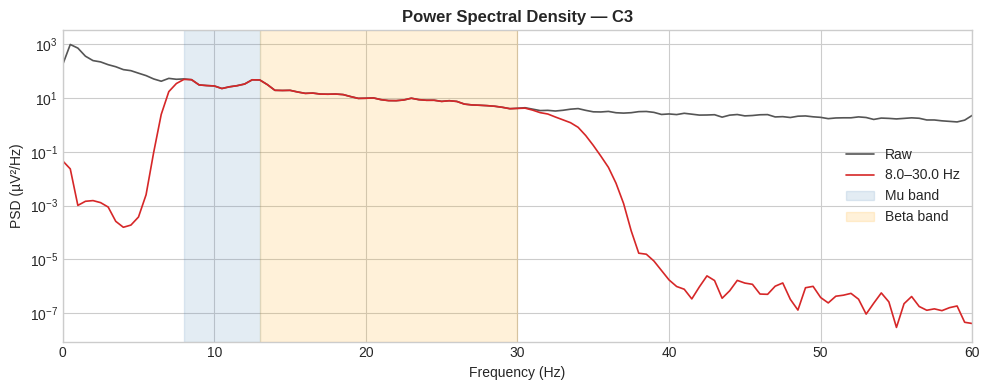

In [6]:
def bandpass_filter(raw, fmin=FMIN, fmax=FMAX):
    """Zero-phase FIR band-pass. Retains mu (8-13 Hz) and beta (13-30 Hz)."""
    return raw.copy().filter(l_freq=fmin, h_freq=fmax,
                              method='fir', fir_window='hamming', verbose=False)

def select_channels(raw, channels=MOTOR_CHS):
    """Keep only motor-cortex channels; fall back gracefully if some missing."""
    avail = [c for c in channels if c in raw.ch_names]
    if len(avail) < len(channels):
        print(f"  [WARN] missing {set(channels)-set(avail)}")
    return raw.copy().pick_channels(avail)

def preprocess(raw):
    """Full pipeline: filter → channel select. Used by both notebook AND Streamlit app."""
    return select_channels(bandpass_filter(raw))

# ── Raw vs filtered plot (C3) ─────────────────────────────────────────────────
raw_filt_d = bandpass_filter(raw_d)
c3r = raw_d.ch_names.index('C3')
c3f = raw_filt_d.ch_names.index('C3')
ts  = raw_d.times
m   = (ts >= 5) & (ts <= 15)

fig, ax = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax[0].plot(ts[m], raw_d.get_data()[c3r, m]*1e6,
           color='#555', lw=0.8, label='Raw')
ax[1].plot(ts[m], raw_filt_d.get_data()[c3f, m]*1e6,
           color='#d62728', lw=0.8, label=f'Filtered {FMIN}–{FMAX} Hz')
for a in ax:
    a.set_ylabel('µV', fontsize=10); a.legend(fontsize=9)
ax[1].set_xlabel('Time (s)', fontsize=10)
fig.suptitle('C3 — Raw vs Band-Pass Filtered', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR/'raw_vs_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PSD comparison ────────────────────────────────────────────────────────────
sfreq_d = raw_d.info['sfreq']
fig, ax = plt.subplots(figsize=(10, 4))
for sig, lbl, col in [
    (raw_d.get_data()[c3r]*1e6,      'Raw',              '#555'),
    (raw_filt_d.get_data()[c3f]*1e6, f'{FMIN}–{FMAX} Hz','#d62728'),
]:
    fr, ps = welch(sig, fs=sfreq_d, nperseg=int(sfreq_d*2))
    ax.semilogy(fr[fr<=60], ps[fr<=60], color=col, lw=1.2, label=lbl)
ax.axvspan(*MU_BAND,   alpha=0.15, color='steelblue', label='Mu band')
ax.axvspan(*BETA_BAND, alpha=0.15, color='orange',    label='Beta band')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (µV²/Hz)')
ax.set_title('Power Spectral Density — C3', fontweight='bold')
ax.legend(); ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig(FIGS_DIR/'psd.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5 · Epoching Around T1 / T2 Events
Window [+0.5, +3.5] s avoids the visual evoked response at cue onset. T1→0 (Left), T2→1 (Right).


In [7]:
def extract_epochs(raw):
    """Extract MNE Epochs for T1/T2 events from a preprocessed Raw object."""
    events, _ = mne.events_from_annotations(raw, event_id=EVENT_ID, verbose=False)
    if len(events) == 0:
        return None
    return mne.Epochs(raw, events, event_id=EVENT_ID,
                      tmin=TMIN, tmax=TMAX, baseline=BASELINE,
                      preload=True, verbose=False)

all_epoch_arrays = []   # (data, labels, subj_id)
epoch_summary    = []

print("Preprocessing and epoching all recordings...")
t0 = time.time()
for subj, run, raw in raw_files:
    raw_pp = preprocess(raw)
    eps    = extract_epochs(raw_pp)
    if eps is None or len(eps) == 0:
        continue
    data   = eps.get_data()
    labels = eps.events[:, 2] - 2    # {2,3} → {0,1}
    all_epoch_arrays.append((data, labels, subj))
    n0, n1 = (labels==0).sum(), (labels==1).sum()
    epoch_summary.append({'subject': subj, 'run': run,
                           'T1': n0, 'T2': n1, 'total': n0+n1})

ep_df = pd.DataFrame(epoch_summary)
print(f"Done in {time.time()-t0:.1f}s — {len(all_epoch_arrays)} recordings")
print(f"Grand total epochs: {ep_df['total'].sum()}")
print(ep_df.head(9).to_string(index=False))

# Reference recording metadata
raw_ref   = preprocess(raw_files[0][2])
PROC_CHS  = raw_ref.ch_names
SFREQ     = raw_ref.info['sfreq']
N_CH      = len(PROC_CHS)
N_TIMES   = all_epoch_arrays[0][0].shape[2]
print(f"\nChannels : {N_CH} → {PROC_CHS}")
print(f"Sfreq    : {SFREQ} Hz   Samples/epoch: {N_TIMES}")


Preprocessing and epoching all recordings...
Done in 4.1s — 60 recordings
Grand total epochs: 900
 subject  run  T1  T2  total
       1    4   8   7     15
       1    8   8   7     15
       1   12   7   8     15
       2    4   7   8     15
       2    8   8   7     15
       2   12   8   7     15
       3    4   8   7     15
       3    8   7   8     15
       3   12   8   7     15

Channels : 9 → ['C3', 'C1', 'Cz', 'C2', 'C4', 'FC3', 'FC4', 'CP3', 'CP4']
Sfreq    : 160.0 Hz   Samples/epoch: 481


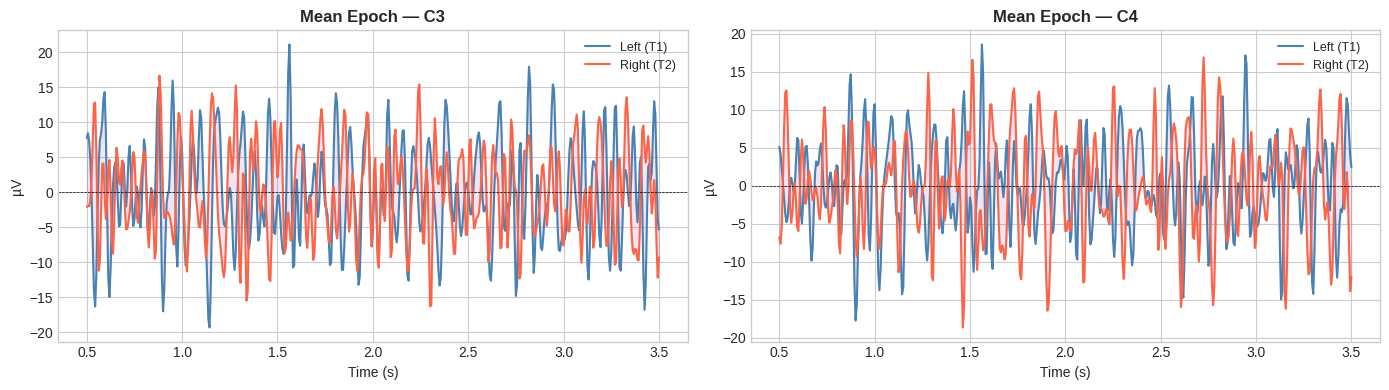

In [8]:
# ── Mean epoch waveform: Left vs Right at C3 / C4 ──────────────────────────
d0, l0, _ = all_epoch_arrays[0]
t_ep = np.linspace(TMIN, TMAX, N_TIMES)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, ch in enumerate(['C3', 'C4']):
    if ch not in PROC_CHS:
        continue
    idx   = PROC_CHS.index(ch)
    left  = d0[l0==0, idx, :].mean(0) * 1e6
    right = d0[l0==1, idx, :].mean(0) * 1e6
    ax[i].plot(t_ep, left,  color='steelblue', lw=1.5, label='Left (T1)')
    ax[i].plot(t_ep, right, color='tomato',    lw=1.5, label='Right (T2)')
    ax[i].fill_between(t_ep, left, right, alpha=0.1, color='purple')
    ax[i].axhline(0, color='k', lw=0.5, ls='--')
    ax[i].set_title(f'Mean Epoch — {ch}', fontweight='bold')
    ax[i].set_xlabel('Time (s)'); ax[i].set_ylabel('µV')
    ax[i].legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR/'erp.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6 · Feature Extraction — Band Power (for classical models)
Welch PSD integrated over mu (8–13 Hz) and beta (13–30 Hz) per channel. Feature vector = `n_channels × 2`.


In [9]:
def band_power(signal, sfreq, band):
    """Integrate Welch PSD over a frequency band. Returns scalar power in µV²."""
    nperseg = min(int(sfreq), len(signal))
    fr, ps  = welch(signal * 1e6, fs=sfreq, nperseg=nperseg)
    mask    = (fr >= band[0]) & (fr <= band[1])
    return float(simpson(ps[mask], x=fr[mask])) if mask.sum() >= 2 else 0.0

def epoch_features(epoch_data, sfreq):
    """(n_ch, n_times) → 1D array [ch0_mu, ch0_beta, ch1_mu, ch1_beta, ...]"""
    return np.array([v for ch in epoch_data
                     for v in (band_power(ch, sfreq, MU_BAND),
                                band_power(ch, sfreq, BETA_BAND))])

def build_feature_matrix(epoch_arrays, sfreq):
    """Stack features for all epochs across all subjects."""
    X, y, g = [], [], []
    for data, labels, sid in epoch_arrays:
        for ep, lab in zip(data, labels):
            X.append(epoch_features(ep, sfreq))
            y.append(lab); g.append(sid)
    return np.array(X), np.array(y), np.array(g)

print("Extracting band-power features (≈ 1–2 min)...")
t0 = time.time()
X, y, groups = build_feature_matrix(all_epoch_arrays, SFREQ)
print(f"Done in {time.time()-t0:.1f}s")
print(f"X shape : {X.shape}   y shape : {y.shape}")
print(f"Class balance — Left={( y==0).sum()}  Right={(y==1).sum()}")
print(f"NaN={np.isnan(X).sum()}  Inf={np.isinf(X).sum()}")

FEAT_NAMES = [f"{ch}_{b}" for ch in PROC_CHS
              for b in ('mu', 'beta')][:X.shape[1]]


Extracting band-power features (≈ 1–2 min)...
Done in 15.8s
X shape : (900, 18)   y shape : (900,)
Class balance — Left=455  Right=445
NaN=0  Inf=0


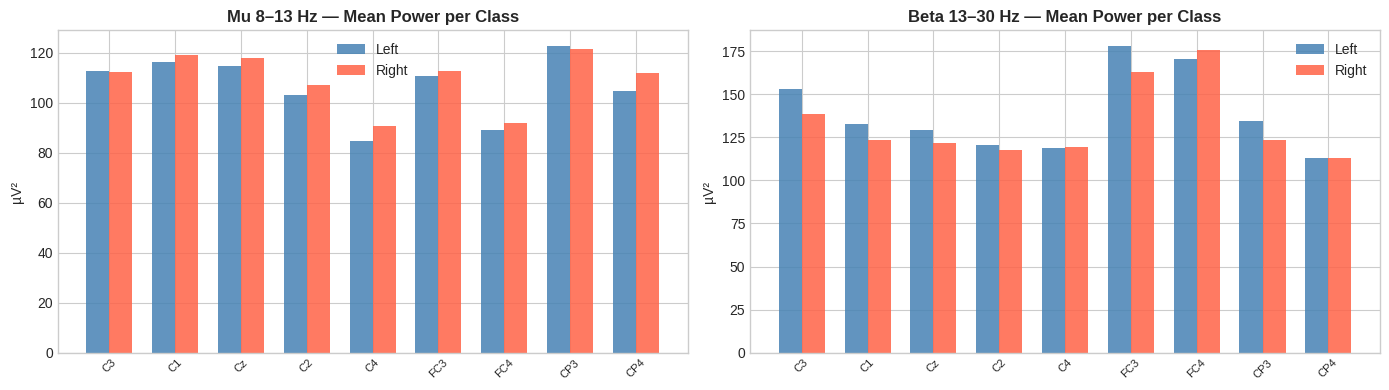

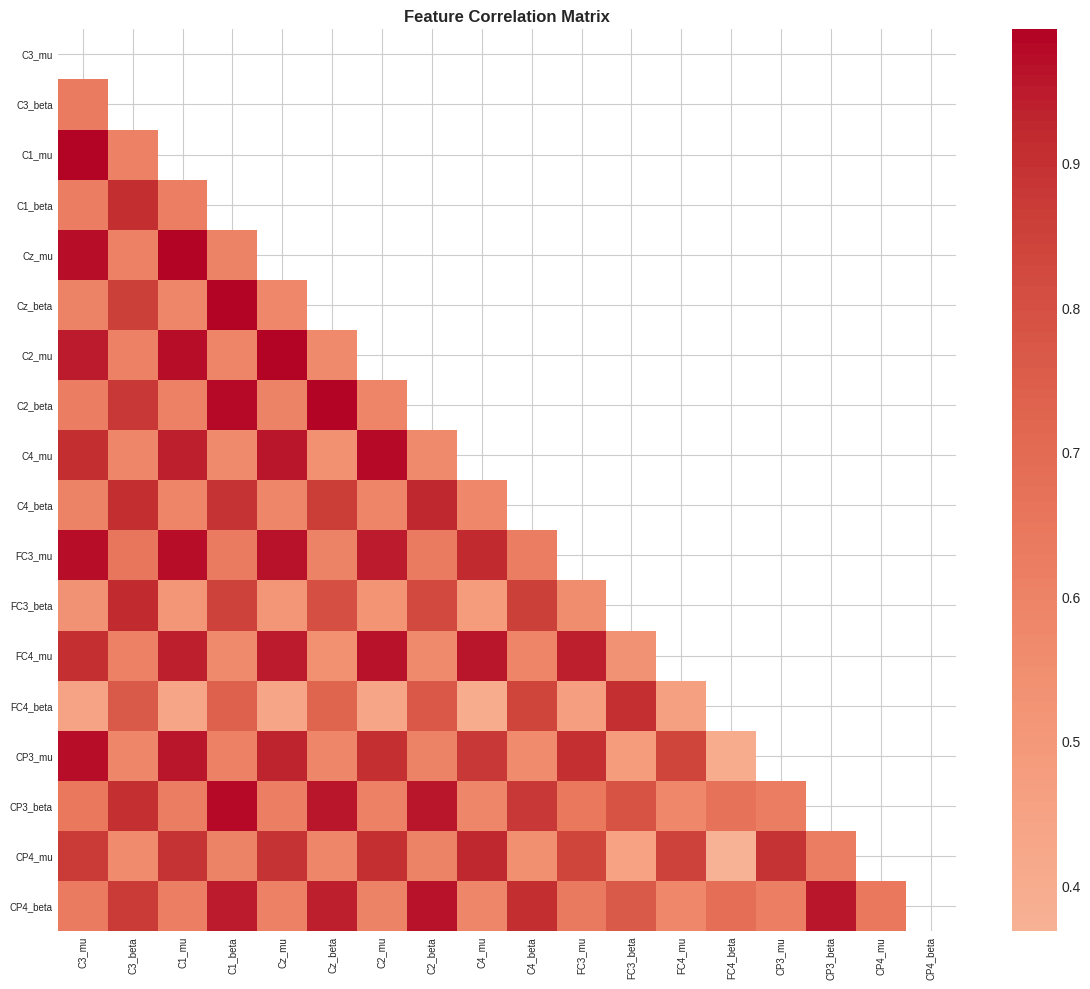

In [10]:
# ── Band-power per class ─────────────────────────────────────────────────────
feat_df = pd.DataFrame(X, columns=FEAT_NAMES)
feat_df['label'] = y
means   = feat_df.groupby('label')[FEAT_NAMES].mean()

mu_f   = [f for f in FEAT_NAMES if f.endswith('_mu')]
beta_f = [f for f in FEAT_NAMES if f.endswith('_beta')]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, feats, title in [
    (ax[0], mu_f,   'Mu 8–13 Hz'),
    (ax[1], beta_f, 'Beta 13–30 Hz'),
]:
    xp, w = np.arange(len(feats)), 0.35
    a.bar(xp-w/2, means.loc[0, feats], w, color='steelblue', alpha=0.85, label='Left')
    a.bar(xp+w/2, means.loc[1, feats], w, color='tomato',    alpha=0.85, label='Right')
    a.set_xticks(xp)
    a.set_xticklabels(
        [f.replace('_mu','').replace('_beta','') for f in feats],
        rotation=45, fontsize=8)
    a.set_title(f'{title} — Mean Power per Class', fontweight='bold')
    a.set_ylabel('µV²')
    a.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR/'band_power_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, a = plt.subplots(figsize=(12, 10))
corr = feat_df[FEAT_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, ax=a,
            xticklabels=FEAT_NAMES, yticklabels=FEAT_NAMES, annot=False)
a.tick_params(labelsize=7)
a.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR/'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7 · Train / Test Split + Advanced Augmentation

**Four augmentation strategies applied to the training set only:**

| Strategy | Detail | Why |
|---|---|---|
| Gaussian noise | σ = 8% of per-feature std | Sensor noise robustness |
| Channel dropout | Zero random features (p = 0.15) | Electrode robustness |
| Amplitude scaling | Uniform ×[0.80, 1.20] per sample | Inter-session variability |
| SMOTE | Synthetic minority oversampling k=5 | Class imbalance |


Train: (720, 18)   Test: (180, 18)
Train balance: Counter({np.int64(0): 364, np.int64(1): 356})   Test: Counter({np.int64(0): 91, np.int64(1): 89})

After noise+dropout+scale aug : 2160 samples
After SMOTE                   : 2184 samples
Final train class balance: Counter({np.int64(0): 1092, np.int64(1): 1092})


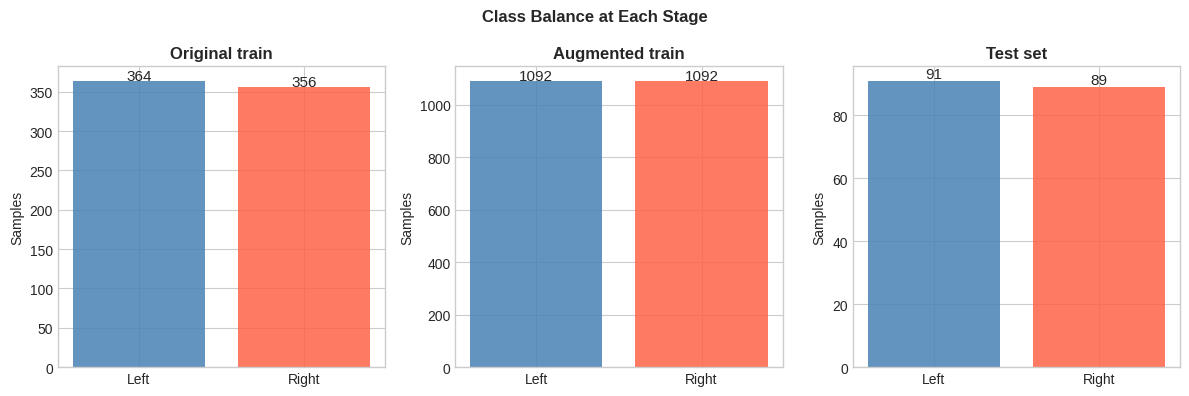

In [11]:
# ── Pooled stratified split ───────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te, g_tr, g_te = train_test_split(
    X, y, groups, test_size=TEST_SIZE, stratify=y, random_state=SEED)

scaler   = StandardScaler().fit(X_tr)
X_tr_sc  = scaler.transform(X_tr)
X_te_sc  = scaler.transform(X_te)

print(f"Train: {X_tr.shape}   Test: {X_te.shape}")
print(f"Train balance: {Counter(y_tr)}   Test: {Counter(y_te)}")

# ── Augmentation ─────────────────────────────────────────────────────────────
def augment_features(X_in, y_in, n_copies=2,
                     noise_frac=0.08, scale_lo=0.80, scale_hi=1.20, drop_p=0.15):
    """
    Produce n_copies augmented copies of the training feature matrix.
    Applied ONLY on training data — never on test data.
    """
    rng = np.random.default_rng(SEED)
    std = X_in.std(0, keepdims=True) + 1e-8
    Xs, ys = [X_in], [y_in]
    for _ in range(n_copies):
        Xc  = X_in + rng.standard_normal(X_in.shape) * std * noise_frac
        Xc *= rng.uniform(scale_lo, scale_hi, (len(Xc), 1))
        Xc[rng.random(Xc.shape) < drop_p] = 0.0
        Xs.append(Xc); ys.append(y_in)
    return np.vstack(Xs), np.hstack(ys)

X_tr_aug, y_tr_aug = augment_features(X_tr, y_tr, n_copies=2)
print(f"\nAfter noise+dropout+scale aug : {len(X_tr_aug)} samples")

# ── SMOTE ────────────────────────────────────────────────────────────────────
if SMOTE_OK:
    try:
        sm = SMOTE(random_state=SEED, k_neighbors=5)
        X_tr_aug, y_tr_aug = sm.fit_resample(X_tr_aug, y_tr_aug)
        print(f"After SMOTE                   : {len(X_tr_aug)} samples")
    except Exception as e:
        print(f"SMOTE failed ({e}); using noise-augmented data.")
else:
    print("SMOTE skipped.")

print(f"Final train class balance: {Counter(y_tr_aug)}")
X_tr_aug_sc = scaler.transform(X_tr_aug)

# ── Class-balance bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, cnts, title in [
    (ax[0], Counter(y_tr),     'Original train'),
    (ax[1], Counter(y_tr_aug), 'Augmented train'),
    (ax[2], Counter(y_te),     'Test set'),
]:
    vals = [cnts.get(0, 0), cnts.get(1, 0)]
    a.bar(['Left', 'Right'], vals, color=['steelblue', 'tomato'], alpha=0.85)
    a.set_title(title, fontweight='bold'); a.set_ylabel('Samples')
    for i, v in enumerate(vals):
        a.text(i, v + 1, str(v), ha='center', fontsize=11)
plt.suptitle('Class Balance at Each Stage', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR/'aug_balance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8 · Classical Models with Optuna Hyperparameter Search

Optuna uses a **TPE (Tree-structured Parzen Estimator)** Bayesian search.  
It learns which parameter regions perform well and focuses trials there — far more efficient than grid search.  
Each model: `OPTUNA_TRIALS` trials × `OPTUNA_CV`-fold stratified CV on the augmented training set.


In [12]:
inner_cv = StratifiedKFold(n_splits=OPTUNA_CV, shuffle=True, random_state=SEED)

def cv_f1(model, Xin, yin):
    """Mean macro-F1 across inner-CV folds — used as the Optuna objective."""
    scores = []
    for tri, vai in inner_cv.split(Xin, yin):
        model.fit(Xin[tri], yin[tri])
        scores.append(f1_score(yin[vai], model.predict(Xin[vai]),
                               average='macro', zero_division=0))
    return float(np.mean(scores))

# ─────────────────────────────────────────────────────────────────────────────
# 8.1 LDA
# ─────────────────────────────────────────────────────────────────────────────
def lda_obj(trial):
    solver = trial.suggest_categorical('solver', ['svd', 'lsqr', 'eigen'])
    shrink = (trial.suggest_float('shrinkage', 0.0, 1.0)
              if solver in ('lsqr', 'eigen') else None)
    return cv_f1(LinearDiscriminantAnalysis(solver=solver, shrinkage=shrink),
                 X_tr_aug_sc, y_tr_aug)

print("Optimising LDA ...")
st_lda = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=SEED))
st_lda.optimize(lda_obj, n_trials=OPTUNA_TRIALS)
bp = st_lda.best_params
lda_model = LinearDiscriminantAnalysis(
    solver=bp['solver'],
    shrinkage=bp.get('shrinkage', None))
lda_model.fit(X_tr_aug_sc, y_tr_aug)
print(f"  Best params : {bp}   CV-F1 : {st_lda.best_value:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 8.2 Random Forest
# ─────────────────────────────────────────────────────────────────────────────
def rf_obj(trial):
    return cv_f1(RandomForestClassifier(
        n_estimators     = trial.suggest_int('n_estimators', 100, 500),
        max_depth        = trial.suggest_int('max_depth', 3, 25),
        min_samples_split= trial.suggest_int('min_samples_split', 2, 10),
        max_features     = trial.suggest_categorical('max_features',
                                                      ['sqrt', 'log2', None]),
        class_weight='balanced', random_state=SEED, n_jobs=-1,
    ), X_tr_aug, y_tr_aug)   # RF does not need scaled features

print("\nOptimising Random Forest ...")
st_rf = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
st_rf.optimize(rf_obj, n_trials=OPTUNA_TRIALS)
bp = st_rf.best_params
rf_model = RandomForestClassifier(**bp, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
rf_model.fit(X_tr_aug, y_tr_aug)
print(f"  Best params : {bp}   CV-F1 : {st_rf.best_value:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 8.3 MLP
# ─────────────────────────────────────────────────────────────────────────────
def mlp_obj(trial):
    n_l    = trial.suggest_int('n_layers', 1, 3)
    layers = tuple(trial.suggest_int(f'h{i}', 32, 256) for i in range(n_l))
    return cv_f1(MLPClassifier(
        hidden_layer_sizes=layers,
        alpha             =trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        learning_rate_init=trial.suggest_float('lr',    1e-4, 1e-2, log=True),
        max_iter=300, early_stopping=True, random_state=SEED,
    ), X_tr_aug_sc, y_tr_aug)

print("\nOptimising MLP ...")
st_mlp = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=SEED))
st_mlp.optimize(mlp_obj, n_trials=OPTUNA_TRIALS)
bp = st_mlp.best_params
n_l    = bp['n_layers']
layers = tuple(bp[f'h{i}'] for i in range(n_l))
mlp_model = MLPClassifier(hidden_layer_sizes=layers,
                            alpha=bp['alpha'], learning_rate_init=bp['lr'],
                            max_iter=300, early_stopping=True, random_state=SEED)
mlp_model.fit(X_tr_aug_sc, y_tr_aug)
print(f"  Best params : {bp}   CV-F1 : {st_mlp.best_value:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 8.4 SVM
# ─────────────────────────────────────────────────────────────────────────────
def svm_obj(trial):
    return cv_f1(SVC(
        C           = trial.suggest_float('C', 0.01, 100, log=True),
        gamma       = trial.suggest_categorical('gamma', ['scale', 'auto']),
        kernel      = trial.suggest_categorical('kernel', ['rbf', 'poly']),
        class_weight='balanced', probability=True, random_state=SEED,
    ), X_tr_aug_sc, y_tr_aug)

print("\nOptimising SVM ...")
st_svm = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=SEED))
st_svm.optimize(svm_obj, n_trials=OPTUNA_TRIALS)
bp = st_svm.best_params
svm_model = SVC(**bp, class_weight='balanced', probability=True, random_state=SEED)
svm_model.fit(X_tr_aug_sc, y_tr_aug)
print(f"  Best params : {bp}   CV-F1 : {st_svm.best_value:.4f}")

print("\n All classical models tuned and trained.")


Optimising LDA ...
  Best params : {'solver': 'svd'}   CV-F1 : 0.5326

Optimising Random Forest ...
  Best params : {'n_estimators': 164, 'max_depth': 19, 'min_samples_split': 6, 'max_features': None}   CV-F1 : 0.5962

Optimising MLP ...
  Best params : {'n_layers': 3, 'h0': 235, 'h1': 197, 'h2': 34, 'alpha': 0.003160672357761452, 'lr': 0.001775916867993131}   CV-F1 : 0.5581

Optimising SVM ...
  Best params : {'C': 15.598643197521564, 'gamma': 'auto', 'kernel': 'rbf'}   CV-F1 : 0.5721

✅ All classical models tuned and trained.


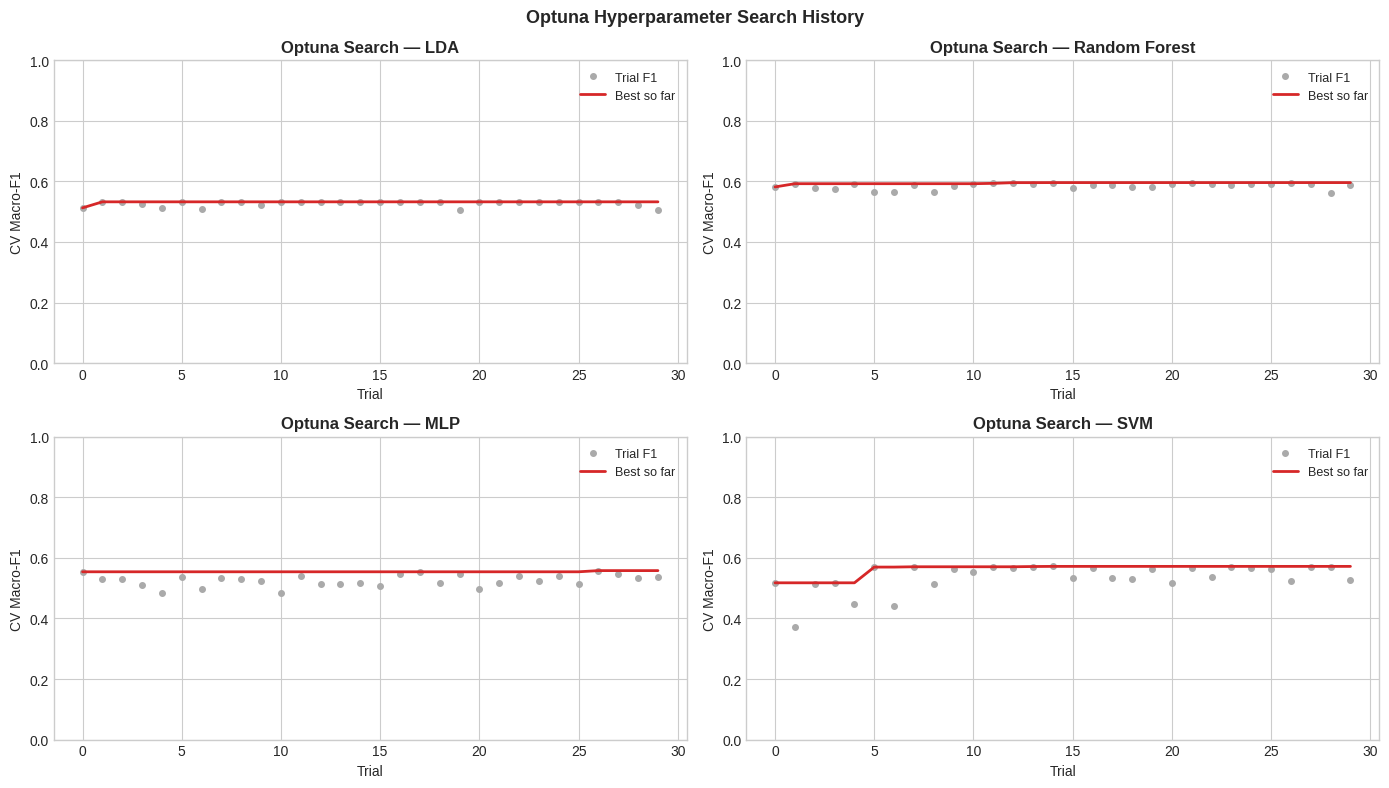

In [13]:
# ── Optuna optimisation history ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, study, name in zip(axes.flat,
    [st_lda, st_rf, st_mlp, st_svm],
    ['LDA', 'Random Forest', 'MLP', 'SVM']):
    vals = [t.value for t in study.trials if t.value is not None]
    best = np.maximum.accumulate(vals)
    ax.plot(vals, 'o', color='#aaa', ms=4, label='Trial F1')
    ax.plot(best, color='#d62728', lw=2, label='Best so far')
    ax.set_title(f'Optuna Search — {name}', fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('CV Macro-F1')
    ax.legend(fontsize=9); ax.set_ylim(0, 1)
plt.suptitle('Optuna Hyperparameter Search History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR/'optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9 · Deep Learning Models — EEGNet · 1D-CNN · BiLSTM + Attention

Three architectures operating on **raw filtered epoch arrays** (no hand-crafted features).

| Model | Input shape | Core idea |
|---|---|---|
| **EEGNet** | (1, C, T) | Temporal → depthwise spatial → separable conv (Lawhern 2018) |
| **1D-CNN** | (C, T) | Stacked 1D temporal convolutions + global average pooling |
| **BiLSTM + Attention** | (T, C) | Bidirectional LSTM with learned temporal self-attention |

Training strategy for all three:
- Class-weighted cross-entropy loss
- AdamW optimiser + cosine annealing LR schedule
- Gradient clipping (max norm 1.0)
- Early stopping with best-weight restoration
- Raw epoch augmentation (noise + channel dropout + amplitude scaling)


In [14]:
# ── Prepare raw epoch tensors ─────────────────────────────────────────────────
if TORCH_OK:
    X_raw_list, y_raw_list, g_raw_list = [], [], []
    for data, labels, sid in all_epoch_arrays:
        X_raw_list.append(data)
        y_raw_list.append(labels)
        g_raw_list.extend([sid] * len(labels))

    X_raw = np.concatenate(X_raw_list, 0)   # (N, C, T)
    y_raw = np.concatenate(y_raw_list, 0)

    # Per-epoch z-score over the time axis
    X_raw_n = (X_raw - X_raw.mean(2, keepdims=True)) / (
                X_raw.std(2, keepdims=True) + 1e-8)

    N_TOT, N_C_DL, N_T_DL = X_raw_n.shape
    print(f"Raw tensor shape : {X_raw_n.shape}  (N, C, T)")

    # 70 / 15 / 15 stratified split
    idx = np.arange(N_TOT)
    idx_tv, idx_te = train_test_split(
        idx, test_size=0.15, stratify=y_raw, random_state=SEED)
    idx_t, idx_v = train_test_split(
        idx_tv, test_size=0.15/0.85, stratify=y_raw[idx_tv], random_state=SEED)

    Xr_t, Xr_v, Xr_e = X_raw_n[idx_t], X_raw_n[idx_v], X_raw_n[idx_te]
    yr_t, yr_v, yr_e  = y_raw[idx_t],  y_raw[idx_v],  y_raw[idx_te]
    print(f"DL split — train:{len(Xr_t)} val:{len(Xr_v)} test:{len(Xr_e)}")

    # ── Raw epoch augmentation (train only) ──────────────────────────────────
    def aug_raw(X_in, y_in, n_copies=2, noise=0.05, drop_p=0.10,
                 slo=0.85, shi=1.15):
        rng = np.random.default_rng(SEED)
        Xs, ys = [X_in], [y_in]
        for _ in range(n_copies):
            Xc  = X_in + rng.standard_normal(X_in.shape) * noise
            dm  = rng.random((Xc.shape[0], Xc.shape[1], 1)) < drop_p
            Xc[dm.squeeze(-1)] = 0.0
            Xc *= rng.uniform(slo, shi, (Xc.shape[0], 1, 1))
            Xs.append(Xc); ys.append(y_in)
        return np.concatenate(Xs, 0), np.concatenate(ys, 0)

    Xr_t_aug, yr_t_aug = aug_raw(Xr_t, yr_t, n_copies=2)
    print(f"DL augmented train : {Xr_t_aug.shape}")
else:
    print("PyTorch not available — deep learning skipped.")


Raw tensor shape : (900, 9, 481)  (N, C, T)
DL split — train:630 val:135 test:135
DL augmented train : (1890, 9, 481)


In [15]:
# ── Model definitions ─────────────────────────────────────────────────────────
if TORCH_OK:

    class EEGNet(nn.Module):
        """
        Compact depthwise-separable CNN for EEG (Lawhern et al. 2018).
        Input: (batch, 1, C, T)
        """
        def __init__(self, C, T, n_cls=2, F1=8, D=2, F2=16, drop=0.4):
            super().__init__()
            # Block 1 — temporal convolution (spectral filter)
            self.b1 = nn.Sequential(
                nn.Conv2d(1, F1, (1, T//2), padding=(0, T//4), bias=False),
                nn.BatchNorm2d(F1))
            # Block 2 — depthwise spatial convolution across channels
            self.b2 = nn.Sequential(
                nn.Conv2d(F1, F1*D, (C, 1), groups=F1, bias=False),
                nn.BatchNorm2d(F1*D), nn.ELU(),
                nn.AvgPool2d((1, 4)), nn.Dropout(drop))
            # Block 3 — separable convolution (spectral combination)
            self.b3 = nn.Sequential(
                nn.Conv2d(F1*D, F1*D, (1, 16), padding=(0, 8),
                           groups=F1*D, bias=False),
                nn.Conv2d(F1*D, F2, (1, 1), bias=False),
                nn.BatchNorm2d(F2), nn.ELU(),
                nn.AvgPool2d((1, 8)), nn.Dropout(drop))
            with torch.no_grad():
                flat = self.b3(self.b2(self.b1(
                    torch.zeros(1, 1, C, T)))).view(1, -1).shape[1]
            self.fc = nn.Linear(flat, n_cls)

        def forward(self, x):
            return self.fc(self.b3(self.b2(self.b1(x))).view(x.size(0), -1))


    class CNN1D(nn.Module):
        """
        Stacked 1D temporal convolutions + global average pooling.
        Input: (batch, C, T)
        """
        def __init__(self, C, T, n_cls=2, drop=0.4):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(C,  32, kernel_size=7, padding=3),
                nn.BatchNorm1d(32),  nn.ELU(),
                nn.Conv1d(32, 64, kernel_size=5, padding=2),
                nn.BatchNorm1d(64),  nn.ELU(),
                nn.MaxPool1d(2),
                nn.Conv1d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm1d(128), nn.ELU(),
                nn.MaxPool1d(2),
                nn.Dropout(drop),
            )
            self.fc = nn.Linear(128, n_cls)

        def forward(self, x):
            return self.fc(self.net(x).mean(dim=-1))   # global avg pool


    class BiLSTM(nn.Module):
        """
        Bidirectional LSTM with temporal self-attention.
        Input: (batch, T, C)  — time-first
        """
        def __init__(self, C, T, n_cls=2, hidden=64, n_layers=2, drop=0.4):
            super().__init__()
            self.ln   = nn.LayerNorm(C)
            self.lstm = nn.LSTM(C, hidden, n_layers, batch_first=True,
                                 bidirectional=True,
                                 dropout=drop if n_layers > 1 else 0.0)
            self.attn = nn.Sequential(
                nn.Linear(hidden*2, 64), nn.Tanh(), nn.Linear(64, 1))
            self.fc   = nn.Sequential(nn.Dropout(drop),
                                       nn.Linear(hidden*2, n_cls))

        def forward(self, x):
            x   = self.ln(x)
            out, _ = self.lstm(x)
            w   = torch.softmax(self.attn(out), dim=1)
            return self.fc((out * w).sum(1))

    print("Model classes defined: EEGNet · CNN1D · BiLSTM")


Model classes defined: EEGNet · CNN1D · BiLSTM


In [16]:
# ── Training engine ───────────────────────────────────────────────────────────
if TORCH_OK:

    class EarlyStopper:
        def __init__(self, patience=20):
            self.patience = patience; self.best = float('inf')
            self.count = 0; self.best_w = None
        def step(self, loss, model):
            if loss < self.best - 1e-4:
                self.best = loss; self.count = 0
                self.best_w = copy.deepcopy(model.state_dict())
            else:
                self.count += 1
            return self.count >= self.patience

    def make_loader(X_np, y_np, bs, shuffle):
        ds = TensorDataset(torch.tensor(X_np, dtype=torch.float32),
                            torch.tensor(y_np, dtype=torch.long))
        return DataLoader(ds, batch_size=bs, shuffle=shuffle, drop_last=shuffle)

    def run_epoch(model, loader, criterion, opt=None):
        model.train() if opt else model.eval()
        tl = tc = tot = 0; probs = []
        ctx = torch.enable_grad() if opt else torch.no_grad()
        with ctx:
            for Xb, yb in loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                if opt: opt.zero_grad()
                lg = model(Xb); loss = criterion(lg, yb)
                if opt:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                tl  += loss.item() * len(yb)
                tc  += (lg.argmax(1) == yb).sum().item()
                tot += len(yb)
                probs.append(torch.softmax(lg, 1)[:, 1].detach().cpu().numpy())
        return tl/tot, tc/tot, np.concatenate(probs)

    def fit_model(model, Xtr, ytr, Xval, yval,
                   name='', epochs=150, bs=32, lr=1e-3, wd=1e-4, patience=25):
        model = model.to(DEVICE)
        wt    = torch.tensor(1.0 / np.bincount(ytr.astype(int)),
                              dtype=torch.float32).to(DEVICE)
        crit  = nn.CrossEntropyLoss(weight=wt)
        opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
        stop  = EarlyStopper(patience)
        trl   = make_loader(Xtr,  ytr,  bs, shuffle=True)
        vll   = make_loader(Xval, yval, bs, shuffle=False)
        hist  = {'tr_loss':[], 'val_loss':[], 'tr_acc':[], 'val_acc':[]}
        for ep in range(epochs):
            tl, ta, _ = run_epoch(model, trl, crit, opt)
            vl, va, _ = run_epoch(model, vll, crit)
            sched.step()
            for k, v in zip(hist, [tl, vl, ta, va]):
                hist[k].append(v)
            if (ep+1) % 25 == 0:
                print(f"  [{name}] ep{ep+1:3d}  "
                      f"tr_loss={tl:.3f}  val_loss={vl:.3f}  val_acc={va:.3f}")
            if stop.step(vl, model):
                print(f"  [{name}] Early stop ep{ep+1}  "
                      f"best_val_loss={stop.best:.4f}")
                model.load_state_dict(stop.best_w)
                break
        return hist

    def predict_dl(model, X_np, bs=64):
        model.eval()
        loader = DataLoader(
            TensorDataset(torch.tensor(X_np, dtype=torch.float32)),
            batch_size=bs, shuffle=False)
        preds, probs = [], []
        with torch.no_grad():
            for (Xb,) in loader:
                lg = model(Xb.to(DEVICE))
                preds.append(lg.argmax(1).cpu().numpy())
                probs.append(torch.softmax(lg, 1)[:, 1].cpu().numpy())
        return np.concatenate(preds), np.concatenate(probs)

    print("Training engine ready.")


Training engine ready.


In [17]:
# ── Train EEGNet ──────────────────────────────────────────────────────────────
if TORCH_OK:
    print("=== Training EEGNet ===")
    eegnet = EEGNet(C=N_C_DL, T=N_T_DL, F1=8, D=2, F2=16, drop=0.4)
    print(f"  Parameters: {sum(p.numel() for p in eegnet.parameters()):,}")
    Xe_tr  = Xr_t_aug[:, np.newaxis, :, :]   # (N, 1, C, T)
    Xe_val = Xr_v[:, np.newaxis, :, :]
    Xe_te  = Xr_e[:, np.newaxis, :, :]
    hist_eegnet = fit_model(eegnet, Xe_tr, yr_t_aug, Xe_val, yr_v,
                             name='EEGNet', epochs=150, bs=32, lr=1e-3, patience=25)


=== Training EEGNet ===
  Parameters: 3,138
  [EEGNet] ep 25  tr_loss=0.500  val_loss=0.788  val_acc=0.504
  [EEGNet] Early stop ep29  best_val_loss=0.6865


In [18]:
# ── Train 1D-CNN ──────────────────────────────────────────────────────────────
if TORCH_OK:
    print("=== Training 1D-CNN ===")
    cnn1d = CNN1D(C=N_C_DL, T=N_T_DL, drop=0.4)
    print(f"  Parameters: {sum(p.numel() for p in cnn1d.parameters()):,}")
    hist_cnn1d = fit_model(cnn1d, Xr_t_aug, yr_t_aug, Xr_v, yr_v,
                            name='1D-CNN', epochs=150, bs=32, lr=1e-3, patience=25)


=== Training 1D-CNN ===
  Parameters: 37,762
  [1D-CNN] ep 25  tr_loss=0.521  val_loss=0.933  val_acc=0.489
  [1D-CNN] Early stop ep29  best_val_loss=0.7032


In [19]:
# ── Train BiLSTM ─────────────────────────────────────────────────────────────
if TORCH_OK:
    print("=== Training BiLSTM ===")
    bilstm = BiLSTM(C=N_C_DL, T=N_T_DL, hidden=64, n_layers=2, drop=0.4)
    print(f"  Parameters: {sum(p.numel() for p in bilstm.parameters()):,}")
    Xl_tr  = Xr_t_aug.transpose(0, 2, 1)   # (N, T, C)
    Xl_val = Xr_v.transpose(0, 2, 1)
    Xl_te  = Xr_e.transpose(0, 2, 1)
    hist_bilstm = fit_model(bilstm, Xl_tr, yr_t_aug, Xl_val, yr_v,
                             name='BiLSTM', epochs=150, bs=32, lr=5e-4, patience=25)


=== Training BiLSTM ===
  Parameters: 146,325
  [BiLSTM] ep 25  tr_loss=0.386  val_loss=0.956  val_acc=0.570
  [BiLSTM] Early stop ep34  best_val_loss=0.6779


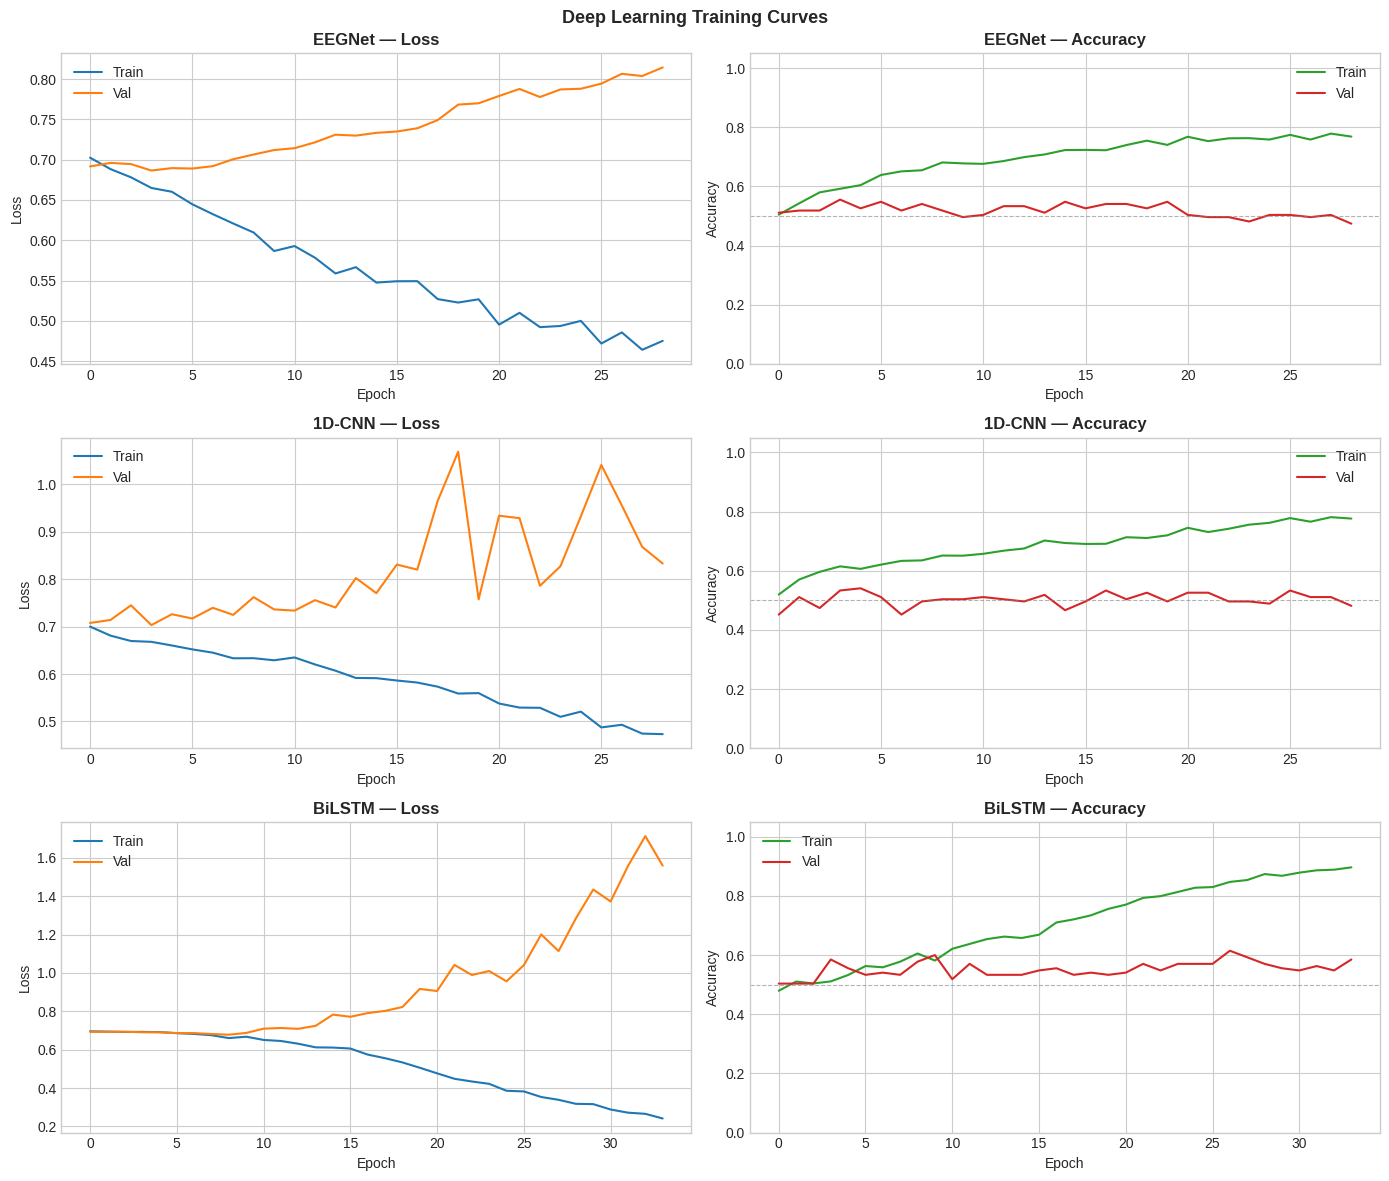

In [20]:
# ── Training curves for all deep models ──────────────────────────────────────
if TORCH_OK:
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    for row, (hist, name) in enumerate([
        (hist_eegnet, 'EEGNet'),
        (hist_cnn1d,  '1D-CNN'),
        (hist_bilstm, 'BiLSTM'),
    ]):
        axes[row, 0].plot(hist['tr_loss'],  lw=1.5, color='#1f77b4', label='Train')
        axes[row, 0].plot(hist['val_loss'], lw=1.5, color='#ff7f0e', label='Val')
        axes[row, 0].set_title(f'{name} — Loss', fontweight='bold')
        axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
        axes[row, 0].legend()

        axes[row, 1].plot(hist['tr_acc'],  lw=1.5, color='#2ca02c', label='Train')
        axes[row, 1].plot(hist['val_acc'], lw=1.5, color='#d62728', label='Val')
        axes[row, 1].set_title(f'{name} — Accuracy', fontweight='bold')
        axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Accuracy')
        axes[row, 1].set_ylim(0, 1.05)
        axes[row, 1].axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6)
        axes[row, 1].legend()

    plt.suptitle('Deep Learning Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/'dl_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 10 · Evaluation — All 7 Models


In [21]:
results_list = []

# ── Classical models ──────────────────────────────────────────────────────────
print("Classical model results:")
for name, model, Xte_in in [
    ('LDA',           lda_model, X_te_sc),
    ('Random Forest', rf_model,  X_te),
    ('MLP',           mlp_model, X_te_sc),
    ('SVM',           svm_model, X_te_sc),
]:
    y_pred = model.predict(Xte_in)
    y_prob = model.predict_proba(Xte_in)[:, 1] if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro')
    auc = roc_auc_score(y_te, y_prob) if y_prob is not None else float('nan')
    results_list.append({'model': name, 'type': 'Classical',
                          'accuracy': acc, 'f1': f1, 'roc_auc': auc,
                          'y_pred': y_pred, 'y_prob': y_prob, 'y_true': y_te})
    print(f"  {name:20s}  acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}")

# ── Deep learning models ──────────────────────────────────────────────────────
if TORCH_OK:
    print("\nDeep learning model results:")
    for name, model, Xte_dl, yte_dl in [
        ('EEGNet',  eegnet, Xe_te, yr_e),
        ('1D-CNN',  cnn1d,  Xr_e,  yr_e),
        ('BiLSTM',  bilstm, Xl_te, yr_e),
    ]:
        y_pred, y_prob = predict_dl(model, Xte_dl)
        acc = accuracy_score(yte_dl, y_pred)
        f1  = f1_score(yte_dl, y_pred, average='macro')
        auc = roc_auc_score(yte_dl, y_prob)
        results_list.append({'model': name, 'type': 'Deep',
                              'accuracy': acc, 'f1': f1, 'roc_auc': auc,
                              'y_pred': y_pred, 'y_prob': y_prob, 'y_true': yte_dl})
        print(f"  {name:20s}  acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}")

# ── Summary DataFrame ─────────────────────────────────────────────────────────
results_df = pd.DataFrame([
    {k: round(v, 4) if isinstance(v, float) else v
     for k, v in r.items()
     if k not in ('y_pred', 'y_prob', 'y_true')}
    for r in results_list
]).sort_values('f1', ascending=False).reset_index(drop=True)

print("\n=== FULL RESULTS TABLE (sorted by F1) ===")
print(results_df.to_string(index=False))


Classical model results:
  LDA                   acc=0.5556  f1=0.5547  auc=0.5780
  Random Forest         acc=0.5444  f1=0.5442  auc=0.5512
  MLP                   acc=0.5389  f1=0.5347  auc=0.5706
  SVM                   acc=0.5333  f1=0.5328  auc=0.5234

Deep learning model results:
  EEGNet                acc=0.5185  f1=0.5181  auc=0.5154
  1D-CNN                acc=0.4815  f1=0.4780  auc=0.5189
  BiLSTM                acc=0.5556  f1=0.5553  auc=0.5689

=== FULL RESULTS TABLE (sorted by F1) ===
        model      type  accuracy     f1  roc_auc
       BiLSTM      Deep    0.5556 0.5553   0.5689
          LDA Classical    0.5556 0.5547   0.5780
Random Forest Classical    0.5444 0.5442   0.5512
          MLP Classical    0.5389 0.5347   0.5706
          SVM Classical    0.5333 0.5328   0.5234
       EEGNet      Deep    0.5185 0.5181   0.5154
       1D-CNN      Deep    0.4815 0.4780   0.5189


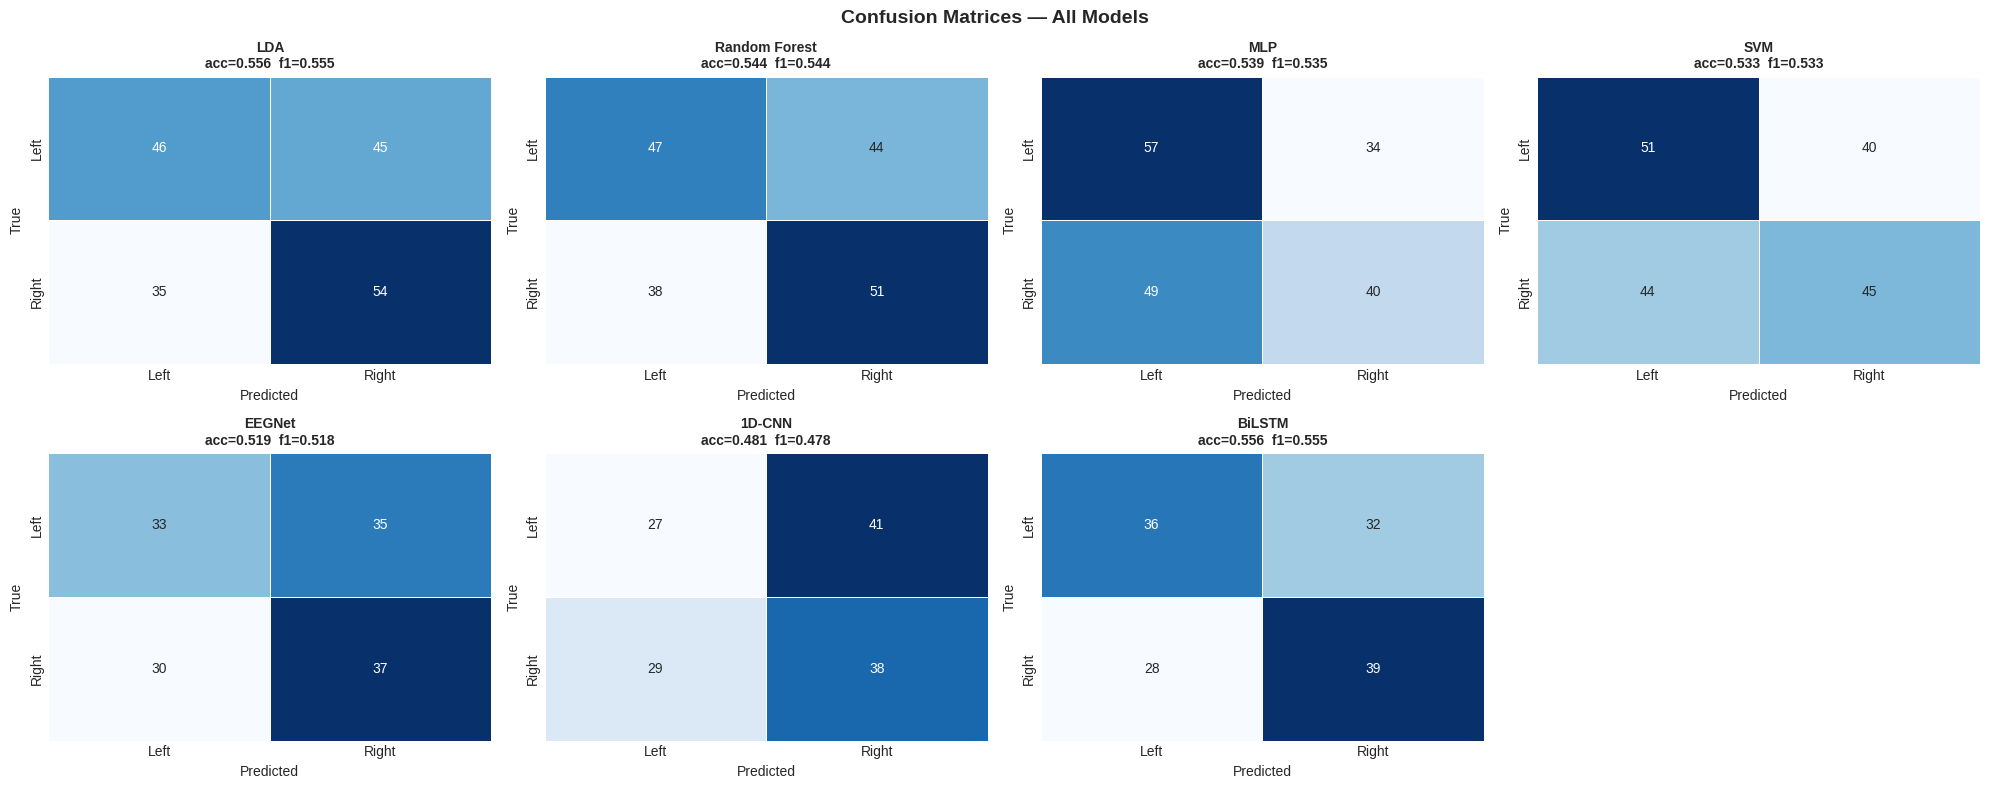

In [22]:
# ── Confusion matrices ───────────────────────────────────────────────────────
n_m   = len(results_list)
ncols = 4
nrows = (n_m + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = list(axes.flat)

for ax, r in zip(axes_flat, results_list):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Left', 'Right'],
                yticklabels=['Left', 'Right'],
                cbar=False, linewidths=0.5)
    ax.set_title(f"{r['model']}\nacc={r['accuracy']:.3f}  f1={r['f1']:.3f}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

for ax in axes_flat[n_m:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR/'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


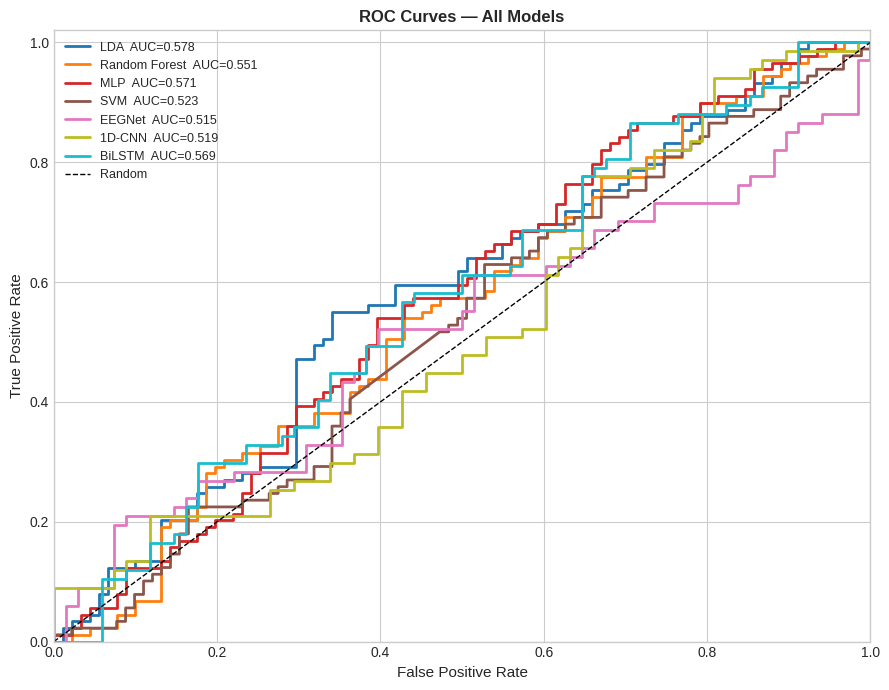

In [23]:
# ── ROC curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

for r, col in zip(results_list, colors):
    if r['y_prob'] is None:
        continue
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'])
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f"{r['model']}  AUC={r['roc_auc']:.3f}")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR/'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


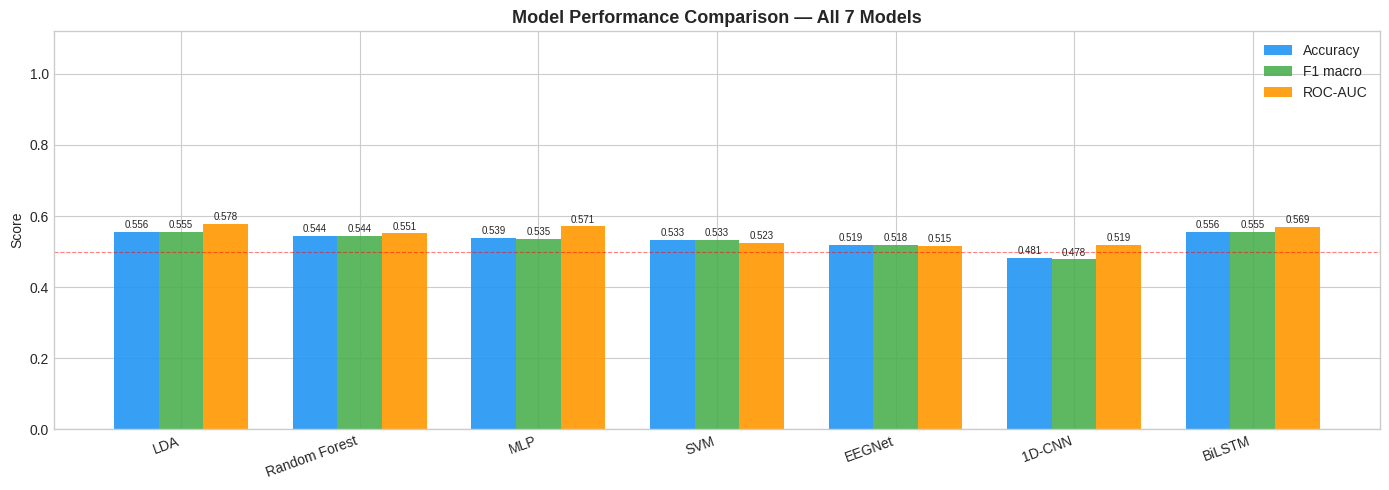

In [24]:
# ── Accuracy / F1 / AUC grouped bar chart ────────────────────────────────────
names = [r['model']   for r in results_list]
accs  = [r['accuracy'] for r in results_list]
f1s   = [r['f1']       for r in results_list]
aucs  = [r['roc_auc']  for r in results_list]

x, w = np.arange(len(names)), 0.25
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x-w, accs, w, label='Accuracy', color='#2196F3', alpha=0.9)
b2 = ax.bar(x,   f1s,  w, label='F1 macro', color='#4CAF50', alpha=0.9)
b3 = ax.bar(x+w, aucs, w, label='ROC-AUC',  color='#FF9800', alpha=0.9)

for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.axhline(0.5, color='red', ls='--', lw=0.8, alpha=0.5, label='Chance')
ax.set_title('Model Performance Comparison — All 7 Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR/'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── RF feature importances ────────────────────────────────────────────────────
top_n = min(20, len(FEAT_NAMES))
imp   = rf_model.feature_importances_
idx   = np.argsort(imp)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(top_n), imp[idx][::-1], color='#2196F3', alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels([FEAT_NAMES[i] for i in idx][::-1], fontsize=9)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title(f'Random Forest — Top {top_n} Feature Importances',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR/'feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11 · Leave-One-Subject-Out Cross-Validation
Measures cross-subject generalisation — the realistic scenario when the app sees a new unseen user.


Running LOSO CV for LDA and RF ...
  LDA: 0.5411 ± 0.0909
  RF: 0.5222 ± 0.0642


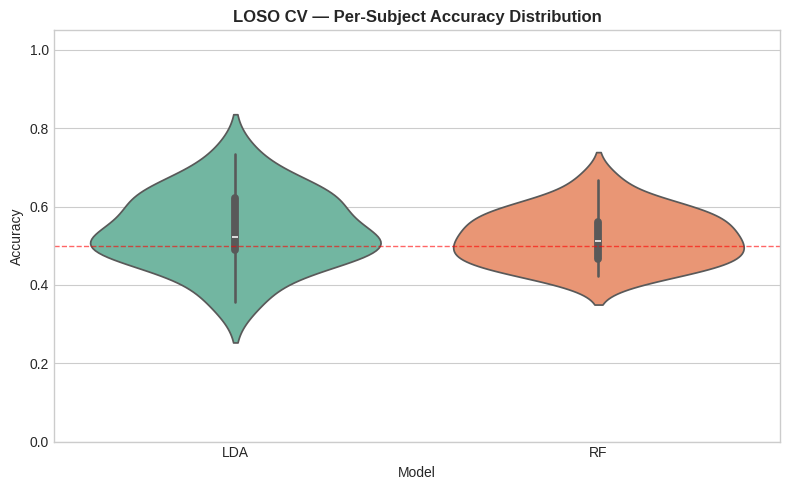

In [25]:
logo   = LeaveOneGroupOut()
loso_r = {}

print("Running LOSO CV for LDA and RF ...")
for mname, use_scale in [('LDA', True), ('RF', False)]:
    fold_acc = []
    for tri, tei in logo.split(X, y, groups):
        Xtr_, Xte_ = X[tri], X[tei]
        ytr_, yte_ = y[tri], y[tei]
        sc_ = StandardScaler().fit(Xtr_)
        Xs_, Xe_   = sc_.transform(Xtr_), sc_.transform(Xte_)
        if mname == 'LDA':
            bp = st_lda.best_params
            m  = LinearDiscriminantAnalysis(solver=bp['solver'],
                                             shrinkage=bp.get('shrinkage', None))
            m.fit(Xs_, ytr_); fold_acc.append(accuracy_score(yte_, m.predict(Xe_)))
        else:
            bp = st_rf.best_params
            m  = RandomForestClassifier(**bp, class_weight='balanced',
                                          random_state=SEED, n_jobs=-1)
            m.fit(Xtr_, ytr_); fold_acc.append(accuracy_score(yte_, m.predict(Xte_)))
    loso_r[mname] = fold_acc
    print(f"  {mname}: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")

# Violin plot
fig, ax = plt.subplots(figsize=(8, 5))
loso_df = pd.DataFrame(loso_r).melt(var_name='Model', value_name='Accuracy')
sns.violinplot(data=loso_df, x='Model', y='Accuracy', palette='Set2',
               ax=ax, inner='box')
ax.axhline(0.5, color='red', ls='--', lw=1, alpha=0.6)
ax.set_title('LOSO CV — Per-Subject Accuracy Distribution', fontweight='bold')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGS_DIR/'loso_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 12 · Automatic Best-Model Selection
Best model is chosen by **test macro-F1** — more robust than accuracy under class imbalance.


In [26]:
# ── Results already sorted by F1 ─────────────────────────────────────────────
best_row  = results_df.iloc[0]
BEST_NAME = best_row['model']

print("=" * 55)
print(f"  WINNER      : {BEST_NAME}")
print(f"  F1 (macro)  : {best_row['f1']:.4f}")
print(f"  Accuracy    : {best_row['accuracy']:.4f}")
print(f"  ROC-AUC     : {best_row['roc_auc']:.4f}")
print("=" * 55)

best_result = next(r for r in results_list if r['model'] == BEST_NAME)
print(f"\nFull classification report — {BEST_NAME}:")
print(classification_report(best_result['y_true'], best_result['y_pred'],
                              target_names=['Left (T1)', 'Right (T2)']))

# ── Final ranked table with winner highlighted ────────────────────────────────
print("\nFull ranked results:")
print(results_df.to_string(index=False))


  WINNER      : BiLSTM
  F1 (macro)  : 0.5553
  Accuracy    : 0.5556
  ROC-AUC     : 0.5689

Full classification report — BiLSTM:
              precision    recall  f1-score   support

   Left (T1)       0.56      0.53      0.55        68
  Right (T2)       0.55      0.58      0.57        67

    accuracy                           0.56       135
   macro avg       0.56      0.56      0.56       135
weighted avg       0.56      0.56      0.56       135


Full ranked results:
        model      type  accuracy     f1  roc_auc
       BiLSTM      Deep    0.5556 0.5553   0.5689
          LDA Classical    0.5556 0.5547   0.5780
Random Forest Classical    0.5444 0.5442   0.5512
          MLP Classical    0.5389 0.5347   0.5706
          SVM Classical    0.5333 0.5328   0.5234
       EEGNet      Deep    0.5185 0.5181   0.5154
       1D-CNN      Deep    0.4815 0.4780   0.5189


---
## 13 · Save All Models, Scaler & Metadata


In [27]:
# ── Classical models + scaler ─────────────────────────────────────────────────
joblib.dump(lda_model, MODELS_DIR/'lda_model.pkl')
joblib.dump(rf_model,  MODELS_DIR/'rf_model.pkl')
joblib.dump(mlp_model, MODELS_DIR/'mlp_model.pkl')
joblib.dump(svm_model, MODELS_DIR/'svm_model.pkl')
joblib.dump(scaler,    MODELS_DIR/'scaler.pkl')

# ── Deep learning models ──────────────────────────────────────────────────────
if TORCH_OK:
    torch.save(eegnet.state_dict(),  MODELS_DIR/'eegnet_model.pth')
    torch.save(cnn1d.state_dict(),   MODELS_DIR/'cnn1d_model.pth')
    torch.save(bilstm.state_dict(),  MODELS_DIR/'bilstm_model.pth')
    dl_cfg = {
        'n_channels': N_C_DL, 'n_times': N_T_DL, 'n_classes': 2,
        'eegnet': {'F1': 8, 'D': 2, 'F2': 16, 'drop': 0.4},
        'cnn1d':  {'drop': 0.4},
        'bilstm': {'hidden': 64, 'n_layers': 2, 'drop': 0.4},
    }
    with open(MODELS_DIR/'dl_model_config.json', 'w') as f:
        json.dump(dl_cfg, f, indent=2)

# ── Metadata JSON (loaded by Streamlit app) ───────────────────────────────────
meta = {
    'channels':      PROC_CHS,
    'n_channels':    N_CH,
    'filter_fmin':   FMIN,
    'filter_fmax':   FMAX,
    'mu_band':       list(MU_BAND),
    'beta_band':     list(BETA_BAND),
    'epoch_tmin':    TMIN,
    'epoch_tmax':    TMAX,
    'event_id':      EVENT_ID,
    'subjects_train':SUBJECTS,
    'runs_train':    RUNS,
    'sfreq':         SFREQ,
    'feature_names': FEAT_NAMES,
    'n_features':    len(FEAT_NAMES),
    'best_model':    BEST_NAME,
    'label_map':     {'0': 'Left (T1)', '1': 'Right (T2)'},
    'results':       results_df.to_dict(orient='records'),
    'loso_rf_mean':  round(float(np.mean(loso_r['RF'])),  4),
    'loso_rf_std':   round(float(np.std(loso_r['RF'])),   4),
    'loso_lda_mean': round(float(np.mean(loso_r['LDA'])), 4),
    'loso_lda_std':  round(float(np.std(loso_r['LDA'])),  4),
}
with open(MODELS_DIR/'model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

results_df.to_csv(RESULTS_DIR/'offline_model_results.csv', index=False)

print("Saved artefacts:")
for d in [MODELS_DIR, RESULTS_DIR, FIGS_DIR]:
    for fp in sorted(d.glob('*')):
        if fp.is_file():
            print(f"  {str(fp):52s}  {fp.stat().st_size/1024:7.1f} KB")


Saved artefacts:
  models/bilstm_model.pth                                 576.8 KB
  models/cnn1d_model.pth                                  157.1 KB
  models/dl_model_config.json                               0.2 KB
  models/eegnet_model.pth                                  19.9 KB
  models/lda_model.pkl                                      1.7 KB
  models/mlp_model.pkl                                   1362.1 KB
  models/model_metadata.json                                2.0 KB
  models/rf_model.pkl                                    6281.4 KB
  models/scaler.pkl                                         1.0 KB
  models/svm_model.pkl                                    308.6 KB
  results/offline_model_results.csv                         0.3 KB
  results/figures/aug_balance.png                          51.7 KB
  results/figures/band_power_per_class.png                 45.7 KB
  results/figures/confusion_matrices.png                   85.6 KB
  results/figures/dl_training_curves.png     

---
## 14 · Per-Epoch Prediction Table
Simulates exactly what the Streamlit app does when a user uploads an EDF file.


S1 R4 — 15 epochs
  RF  epoch acc : 0.9333
  LDA epoch acc : 0.6000
 epoch  start_s  end_s ground_truth pred_rf pred_lda  correct_rf  correct_lda
     1      4.2    7.2        Right   Right     Left        True        False
     2     12.5   15.5         Left    Left     Left        True         True
     3     20.8   23.8         Left   Right     Left       False         True
     4     29.1   32.1        Right   Right    Right        True         True
     5     37.4   40.4        Right   Right     Left        True        False
     6     45.7   48.7         Left    Left     Left        True         True
     7     54.0   57.0        Right   Right    Right        True         True
     8     62.3   65.3         Left    Left    Right        True        False
     9     70.6   73.6        Right   Right     Left        True        False
    10     78.9   81.9         Left    Left     Left        True         True
    11     87.2   90.2         Left    Left    Right        True        Fa

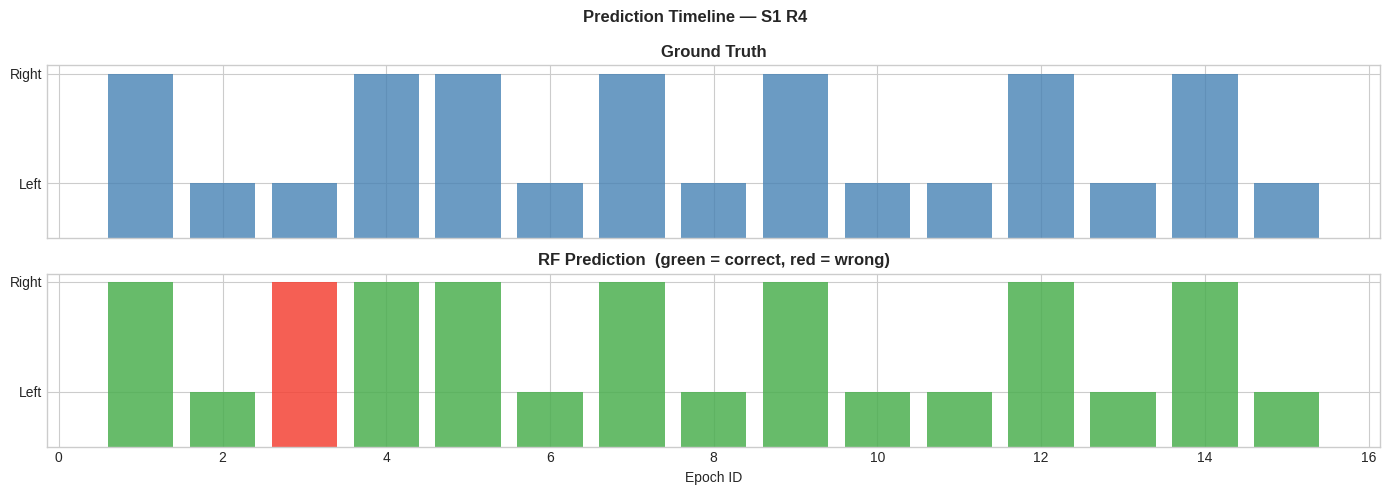

In [28]:
# ── Run inference on subject 1 run 4 ─────────────────────────────────────────
DEMO_S, DEMO_R = 1, 4
demo_raw = next((r for s, rn, r in raw_files
                 if s == DEMO_S and rn == DEMO_R), raw_files[0][2])

raw_pp  = preprocess(demo_raw)
eps     = extract_epochs(raw_pp)

if eps is not None and len(eps) > 0:
    data_d   = eps.get_data()
    lbl_d    = eps.events[:, 2] - 2
    onsets   = eps.events[:, 0] / SFREQ

    Xd       = np.array([epoch_features(ep, SFREQ) for ep in data_d])
    Xd_sc    = scaler.transform(Xd)

    rf_preds  = rf_model.predict(Xd)
    lda_preds = lda_model.predict(Xd_sc)

    lmap = {0: 'Left', 1: 'Right'}
    ptab = pd.DataFrame({
        'epoch':       range(1, len(lbl_d)+1),
        'start_s':     onsets.round(2),
        'end_s':       (onsets + TMAX - TMIN).round(2),
        'ground_truth':[lmap[l] for l in lbl_d],
        'pred_rf':     [lmap[p] for p in rf_preds],
        'pred_lda':    [lmap[p] for p in lda_preds],
    })
    ptab['correct_rf']  = ptab['ground_truth'] == ptab['pred_rf']
    ptab['correct_lda'] = ptab['ground_truth'] == ptab['pred_lda']
    ptab.to_csv(RESULTS_DIR/'per_epoch_predictions.csv', index=False)

    print(f"S{DEMO_S} R{DEMO_R} — {len(ptab)} epochs")
    print(f"  RF  epoch acc : {ptab['correct_rf'].mean():.4f}")
    print(f"  LDA epoch acc : {ptab['correct_lda'].mean():.4f}")
    print(ptab.to_string(index=False))

    # ── Prediction timeline ───────────────────────────────────────────────────
    lmap_n = {'Left': 0, 'Right': 1}
    gt_n   = ptab['ground_truth'].map(lmap_n)
    pr_n   = ptab['pred_rf'].map(lmap_n)
    cols   = ['#4CAF50' if c else '#f44336' for c in ptab['correct_rf']]

    fig, ax = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    ax[0].bar(ptab['epoch'], gt_n + 0.5, color='steelblue', alpha=0.8, width=0.8)
    ax[0].set_yticks([0.5, 1.5]); ax[0].set_yticklabels(['Left', 'Right'])
    ax[0].set_title('Ground Truth', fontweight='bold')

    ax[1].bar(ptab['epoch'], pr_n + 0.5, color=cols, alpha=0.85, width=0.8)
    ax[1].set_yticks([0.5, 1.5]); ax[1].set_yticklabels(['Left', 'Right'])
    ax[1].set_xlabel('Epoch ID')
    ax[1].set_title('RF Prediction  (green = correct, red = wrong)',
                    fontweight='bold')
    plt.suptitle(f'Prediction Timeline — S{DEMO_S} R{DEMO_R}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/'prediction_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 15 · Final Summary

### Pipeline
| Step | Choice | Rationale |
|---|---|---|
| Filter | 8–30 Hz FIR band-pass | Retains mu + beta motor imagery rhythms |
| Channels | 9 motor-cortex channels (C3–C4 neighbourhood) | Covers hand motor area with manageable dimensionality |
| Epoch window | [+0.5, +3.5] s after cue | Avoids visual ERP; captures sustained motor imagery |
| Classical features | Welch band power (mu + beta) per channel | Interpretable, low-dimensional, well-validated |
| Deep features | Raw normalised epochs | CNN/LSTM learn temporal-spatial filters end-to-end |
| Augmentation | Noise + dropout + scaling + SMOTE | Noise robustness, electrode robustness, class balance |
| Hyperparameter search | Optuna TPE (30 trials × 3-fold CV) | Bayesian search, far more efficient than grid search |

### Models
| Model | Type | Tuning |
|---|---|---|
| LDA | Classical | Optuna |
| Random Forest | Classical | Optuna |
| MLP | Classical | Optuna |
| SVM | Classical | Optuna |
| EEGNet CNN | Deep | AdamW + cosine LR + early stop |
| 1D-CNN | Deep | AdamW + cosine LR + early stop |
| BiLSTM + Attention | Deep | AdamW + cosine LR + early stop |

### Saved artefacts
```
models/
  lda_model.pkl   rf_model.pkl   mlp_model.pkl   svm_model.pkl
  scaler.pkl
  eegnet_model.pth   cnn1d_model.pth   bilstm_model.pth
  dl_model_config.json    model_metadata.json   ← loaded by Streamlit app

results/
  offline_model_results.csv      ← displayed in Streamlit offline summary
  per_epoch_predictions.csv      ← app debugging / timeline demo
  figures/  (15 diagnostic plots)
```

> `model_metadata.json` contains the `best_model` key — the Streamlit app reads this  
> to select which model to load by default for inference.
